In [4]:
import rebound
import numpy as np 
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit

# Test parametri di rebound


Vediamo di fare un setup semplice, gas in box periodiche (+ non periodiche?) e di vedere come cambia 

[Link prova](#sezione2)

<a id='sezione2'></a>
# LA sezione due

In [56]:

boxL = 10
sim = rebound.Simulation()
nx, ny = 10, 5
sim.widget(port=1266,size=(1000,1000))
sim.configure_box(boxL,nx,ny)
sim.boundary = "open"
sim.gravity = "tree"
sim.integrator = "leapfrog"
sim.softening = 0.1
sim.opening_angle2 = 1.5
np.random.seed(0)
M = 10
N = 500
m = 100
T = 50
# più cresce M, o N, o Vx, o diminuisce mBH o vBH
# ovvero più il momento è dominato da quello della particelle
# più rispetto al centro di massa si muove veloce BH
# quindi più stelle sono più lente di lui ovvero rho(<vs)
Vx = 15
nrows = 20
ncols = int(N/nrows)
k = 0
xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
# for x in xs:
#     for y in ys:
#         vx = -2*Vx
#         sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/200)
sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
sim.collision = "none"
steps = int(1e4)
# v = np.zeros(steps)
# theta = np.zeros(steps)
v = []
defs = []
theta = 0
i = 0
k = 0
Nparticles = sim.N
cycle = 0
particle_hash = 0
bs = []

# dt = sim.dt
def heartbeat(sim_pointer):
    global v, theta, i, Nparticles, k, cycle, defs, particle_hash,bs
    sim = sim_pointer.contents
    t = sim.t
    dt = boxL**3/(N-1)/(2*Vx)
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/100,hash=particle_hash)
            bs = np.r_[bs, j]
            particle_hash += 1
        t = 0

        Nparticles = sim.N
    
    v = np.append(v,sim.particles["BH"].vx)
    i+=1

sim.heartbeat = heartbeat

sim.integrator = "leapfrog"

REBOUND Webserver listening on http://localhost:1266 ...


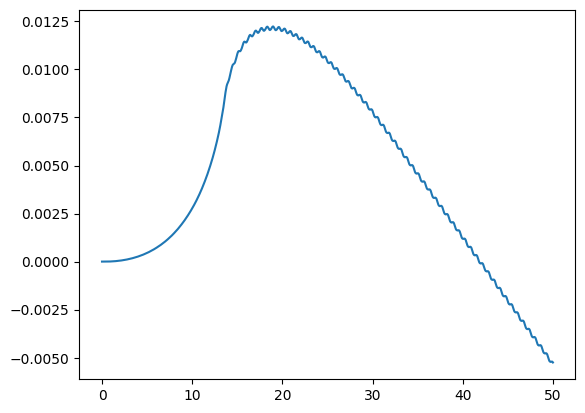

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
0.0
1.0
2.

In [ ]:
fig, ax = plt.subplots()

sim.integrate(T)
# sim.steps(steps)

ts = np.linspace(0,T,len(v))
ax.plot(ts,v)
plt.show()
# fig.savefig(f"N{N}m{m}t{T}.png")

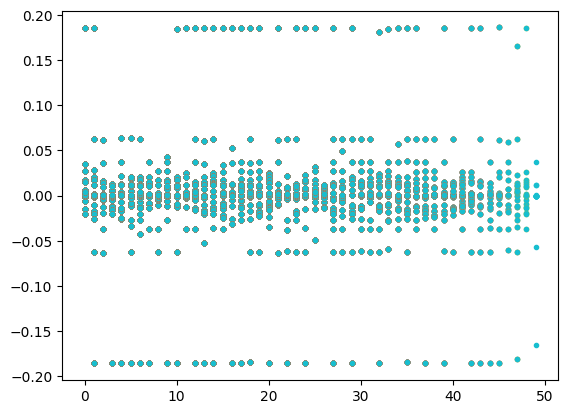

[-301.78789938 -268.84897794 -237.49309889 -200.23255469 -164.58134595
 -128.01607588  -91.46754227  -54.64799521  -18.41129264   18.40902389
   54.64514219   91.4771049   128.01614794  164.58096719  200.23246934
  237.49303735  268.84981052  301.78759242  306.09364759]


/tmp/ipykernel_1516737/2256548188.py:14: RuntimeWarning: divide by zero encountered in divide
  b_over_b90 = 1/np.tan(means/2)


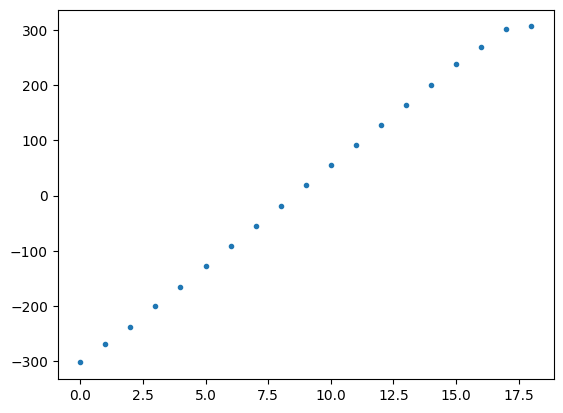

v = 15: m = 35.482448000414095


In [ ]:
means = np.zeros(nrows)
fig, ax = plt.subplots()
for b in range(1,nrows):
    defs = []
    for p in sim.particles:
        if p.hash.value != 1753590236 and bs[p.hash.value]==b:
            # if p.x<0.1*nx*boxL and (True or p.x < -0.99*nx*boxL/2 or np.abs(p.y) > 0.99*ny*boxL/2):
            deflection = np.arctan2(p.vy,p.vx)
            deflection = (np.abs(deflection)-np.pi)*np.sign(deflection)
            defs = np.r_[defs, deflection]
            ax.plot(defs,'.',label=f"{b}")
    means[b] = np.mean(defs)

print(bs)
plt.show()
b_over_b90 = 1/np.tan(means/2)
b_over_b90 = b_over_b90[1:]
Xfit = np.arange(nrows)[1:]
print(b_over_b90)
fig, ax = plt.subplots()
# ax.plot(means,'.')
ax.plot(b_over_b90,'.')
# ax.hist(np.tan(defs/2),bins=10000)
# # ax.plot(np.log(-np.tan(defs)),'.',markersize=0.1)
plt.show()

from scipy.optimize import curve_fit

popt, _ = curve_fit(lambda x, m, q: m*x + q, Xfit, b_over_b90)

print(f"v = {Vx}: m = {popt[0]}")


In [ ]:
m5 = 3.8468458761804656
m10 = 15.423398930537578
m15 = 35.403351715682646

# Preventivo

FRIZIONE DINAMICAAAA

Test:
- prima di cominciare il test mettere in condizione stazionaria
1. conf semplice
2. conf. con "rotazione differenziale"
3. (opzionale) BH che precipita al centro di un disco

variando:
- massa BH
- velocità relativa (testare stelle v=cost, v=Maxwell-Boltzmann)
- densità stelle

Formula di Chandrasekhar funziona in sistema di rif. dove la velocità media delle particelle è 0, aka isotropa, cioè quello che muove a destra di vx0

dipendenza temporale:
- la forza dovrebbe cambiare esattamente quando vBH ~ sigma (se stelle hanno vx MB)
Per ogni test:
- Tracciare posizione, velocità, accelerazioni BH
- Tracciare distribuzione spazio delle fasi delle particelle (y,vx,vy,v)

Roba computazionale:
- studiare complessità del problema al variare dei parametri della simulazione e funzionalità di rebound


In [ ]:

boxL = 10
sim = rebound.Simulation()
nx, ny = 10, 5
sim.widget(port=1264,size=(1000,1000))
sim.configure_box(boxL,nx,ny)
sim.boundary = "open"
sim.gravity = "tree"
sim.integrator = "leapfrog"
sim.softening = 0.1
# sim.opening_angle2 = 1.5
np.random.seed(0)
M = 10
N = 500
m = 100
T = 20
# più cresce M, o N, o Vx, o diminuisce mBH o vBH
# ovvero più il momento è dominato da quello della particelle
# più rispetto al centro di massa si muove veloce BH
# quindi più stelle sono più lente di lui ovvero rho(<vs)
Vx = 2.5
nrows = 20
ncols = int(N/nrows)
k = 0
xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
for x in xs:
    for y in ys:
        vx = -2*Vx
        sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
sim.collision = "none"
steps = int(1e4)
# v = np.zeros(steps)
# theta = np.zeros(steps)
v = []
defs = []
theta = 0
i = 0
k = 0
Nparticles = sim.N
cycle = 0
particle_hash = 0
bs = []

alpha = np.floor(t/tau)

# dt = sim.dt
def heartbeat(sim_pointer):
    global v, theta, i, Nparticles, k, cycle, defs, particle_hash,bs
    sim = sim_pointer.contents
    t = sim.t
    # dt = boxL**3/(N-1)/(2*Vx)
    tau = 0.1
    
    dt = boxL*nx/ncols/(2*Vx)
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50,hash=particle_hash)
            bs = np.r_[bs, j]
            particle_hash += 1
        t = 0

        Nparticles = sim.N
    
    v = np.append(v,sim.particles["BH"].vx)
    i+=1
    print(sim.dt)

sim.heartbeat = heartbeat

sim.integrator = "leapfrog"

REBOUND Webserver listening on http://localhost:1264 ...


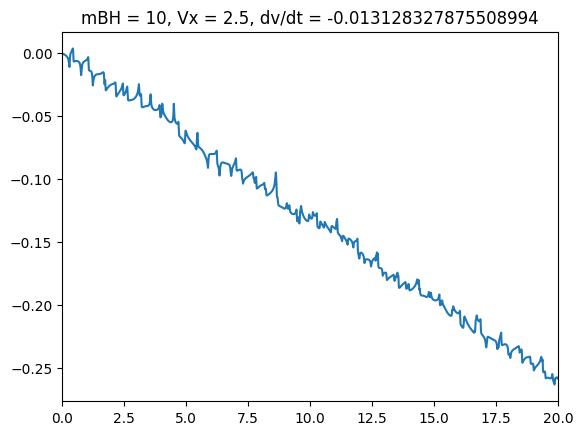

In [ ]:
fig, ax = plt.subplots()

sim.integrate(T)

ts = np.linspace(0,sim.t,len(v))
cut = (ts>0)
popt, _ = curve_fit(lambda x, m, q: m*x + q, ts[cut], v[cut])
m = popt[0]
ax.plot(ts[cut],v[cut])
ax.set_title(f"mBH = {M}, Vx = {Vx}, dv/dt = {m}")
ax.set_xlim(0,20)
plt.show()


M = 10, Vx = 100: dv/dt = -0.00279
M = 10, Vx = 50: dv/dt = -0.00323
M = 10, Vx = 25: dv/dt = -0.00415
M = 10, Vx = 20: dv/dt = -0.00484
M = 10, Vx = 15: dv/dt = -0.00623
M = 10, Vx = 12.5: dv/dt = -0.00772
M = 10, Vx = 10: dv/dt = -0.0102
M = 10, Vx =  5: dv/dt = -0.0227


M = 1, Vx = 100: dv/dt = -0.000263
M = 1, Vx = 50: dv/dt = -0.000327
M = 1, Vx = 25: dv/dt = -0.000413
M = 1, Vx = 20: dv/dt = -0.000480
M = 1, Vx = 15: dv/dt = -0.000633
M = 1, Vx = 12.5: dv/dt = -0.000774
M = 1, Vx = 10: dv/dt = -0.00101
M = 1, Vx =  5: dv/dt = -0.00224

M = 100, Vx = 100: dv/dt = -0.0288

M = 100, Vx = 50: dv/dt = -0.000327
M = 100, Vx = 25: dv/dt = -0.000413
M = 100, Vx = 20: dv/dt = -0.000480
M = 100, Vx = 15: dv/dt = -0.000633
M = 100, Vx = 12.5: dv/dt = -0.000774
M = 100, Vx = 10: dv/dt = -0.00101
M = 100, Vx =  5: dv/dt = -0.00224

# Scan dei parametri

In [ ]:
def heartbeat(sim_pointer):
    global v, cycle
    sim = sim_pointer.contents
    t = sim.t

    dt = boxL*nx/ncols/(2*Vx) #Particle spawning interval

    #Spawn particles
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
        t = 0

    v = np.append(v,sim.particles["BH"].vx) #save BH velocity

Ms = np.linspace(10,100,10) #Massa gas
ms = np.linspace(10,100,10) #Massa BH
Vxs = np.linspace(1,100,100) #Velocità relativa
scanfolder = "scan10000"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

out = []

def line(x,a,q):
    return a*x+q

for M in Ms:
    for m in ms:
        for Vx in Vxs:
            sim = rebound.Simulation()
            sim.heartbeat = heartbeat
            # sim.widget(port=1264,size=(1000,1000))
            sim.configure_box(boxL,nx,ny)
            sim.boundary = "open"
            sim.gravity = "tree"
            sim.integrator = "leapfrog"
            sim.softening = 0.1
            sim.opening_angle2 = 1.5
            sim.collision = "none"

            #Add initial particles
            xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
            ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
            for x in xs:
                for y in ys:
                    vx = -2*Vx
                    sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
            sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
            v = []
            cycle = 0

            sim.integrate(T)

            ts = np.linspace(0,sim.t,len(v))
            cut = (ts>=0)
            popt, _ = curve_fit(line, ts[cut], v[cut])
            a = popt[0]

            title = f"M_gas = {M:0.2f} - M_BH = {m} - Vx = {Vx:0.2f} - a = {a:0.2f}"

            if save_fig:
                fig, ax = plt.subplots()
                ax.plot(ts[cut],v[cut])
                ax.plot(ts[cut],line(ts[cut],*popt),'--r')
                ax.set_title(title)
                filename = f"{scanfolder}/M{M:.0f}m{m:.0f}Vx{Vx:.0f}.png"
                fig.savefig(filename)
                plt.close()
            else:
                print(title)

            results = {
                "M": M,
                "m": m,
                "Vx": Vx,
                "v": v,
                "a": a
            }

            out.append(results)
            if autosave:
                with open(picklefile, 'wb') as handle:
                    pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

if save:
    with open(picklefile, 'wb') as handle:
        pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

M_gas = 10.00 - M_BH = 10.0 - Vx = 1.00 - a = -0.01
M_gas = 10.00 - M_BH = 10.0 - Vx = 2.00 - a = -0.01
M_gas = 10.00 - M_BH = 10.0 - Vx = 3.00 - a = -0.01


KeyboardInterrupt: 

In [211]:
save = True
import pickle
picklefile = f'{scanfolder}.pickle'
if save:
    with open(picklefile, 'wb') as handle:
        pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)


[ 4.59338369  0.013369   -1.21897149]


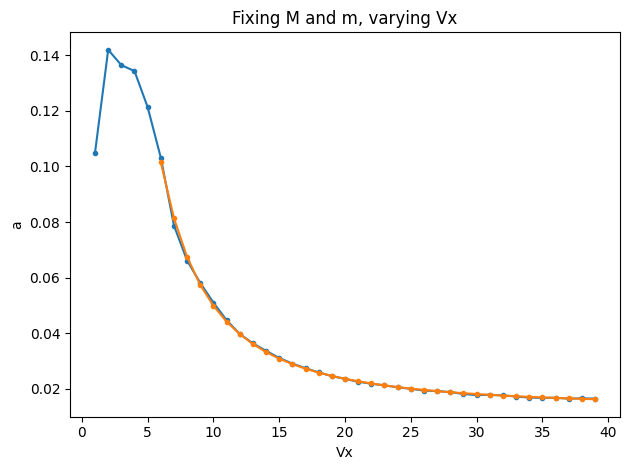

In [ ]:

# for res in out:
#     print(f"{res["M"]}, {res["m"]}, {res["Vx"]}, {-res["a"]}")

# fig, ax = plt.subplots(nrows=len(Vxs),ncols=len(ms),figsize=(100,100))
# for i, Vx in enumerate(Vxs):
#     fixed_Vx = [results for results in out if results["Vx"] == Vx]
#     for j, m in enumerate(ms):
#         fixed_m = [results for results in fixed_Vx if results["m"] == m]
#         a = [results["a"] for results in fixed_m]
#         ax[i,j].plot(a,'*',markersize=100)
# plt.tight_layout()
# plt.show()

# arrays = [Ms, ms, Vxs]
# keys = ["M", "m","Vx"]
# for excluded_array in arrays:
#     reduced = arrays
#     reduced.remove(excluded_array)
#     fixed = out
#     for fixed_quantity in reduced:
#         fixed = [results for results in fixed if results[key] == ]
scanfolder = "good_scan"
scanfolder = "scan20_100_6"
scanfolder = "scanv"
picklefile = f'{scanfolder}.pickle'
with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

# Mout = []
# fig, ax = plt.subplots(2)
# for Vx in Vxs:
#     cs = []
#     fixed1 = [results for results in out if results["Vx"] == Vx]
#     for m in ms:
#         fixed2 = [results for results in fixed1 if results["m"] == m]
#         a = np.array([results["a"] for results in fixed2])
#         xM = np.array([results["M"] for results in fixed2])

#         ax[0].plot(xM,-a,".-")
#         ax[0].set_xlabel("M")
#         ax[0].set_ylabel("a")

#         popt, _ = curve_fit(lambda x, c, q: c*x + q, xM, a)
#         c = popt[0]
#         print(f"{popt[1]*10000:0.2f}")
#         cs.append(c)
#     cs = np.array(cs)
#     ax[1].plot(ms,-cs,'.-')
#     ax[1].set_xlabel("m")
#     ax[1].set_ylabel("c")
# ax[0].set_title("Fixing Vx and m, varying M")
# ax[1].set_title("Angular coefficient")
# # ax[1].set_yscale("log")
# # ax[1].set_xscale("log")
# plt.tight_layout()
# plt.show()

def a_v(x,c0,c1,c2):
    return c0/(x-c2)**2+c1
fig, ax = plt.subplots()
for M in Ms:
    fixed_M = [results for results in out if results["M"] == M]
    for m in ms:
        fixed_m = [results for results in fixed_M if results["m"] == m]
        a = -np.array([results["a"] for results in fixed_m])
        xVx = np.array([results["Vx"] for results in fixed_m])
        cut = xVx > 5
        # cut = xVx > -1
        popt, _ = curve_fit(a_v,xVx[cut],a[cut])
        print(popt)
        ax.plot(xVx,a,".-")
        ax.plot(xVx[cut],a_v(xVx[cut],*popt),".-")
        ax.set_xlabel("Vx")
        ax.set_ylabel("a")
ax.set_title("Fixing M and m, varying Vx")
plt.tight_layout()

plt.show()

# fig, ax = plt.subplots(2)
# for Vx in Vxs:
#     cs = []
#     fixed_Vx = [results for results in out if results["Vx"] == Vx]
#     for M in Ms:
#         fixed_M = [results for results in fixed_Vx if results["M"] == M]
#         a = [results["a"] for results in fixed_M]
#         xm = [results["m"] for results in fixed_M]
#         ax[0].plot(xm,a,".-")
#         ax[0].set_xlabel("m")
#         ax[0].set_ylabel("a")
#         popt, _ = curve_fit(lambda x, c, q: c*x + q, xM, a)
#         c = popt[0]
#         cs.append(c)
#     cs = np.array(cs)
#     ax[1].plot(-cs,'.-')
#     ax[1].set_xlabel("m")
#     ax[1].set_ylabel("c")
# ax[0].set_title("Fixing Vx and M, varying m")
# plt.tight_layout()

plt.show()



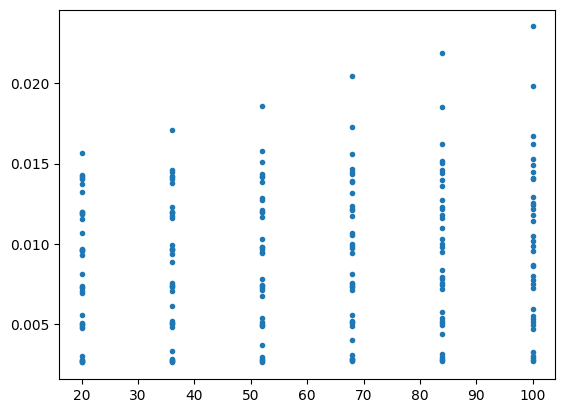

In [246]:
# scanfolder = "good_scan"
scanfolder = "scan20_100_6"
# scanfolder = "scanv"
picklefile = f'{scanfolder}.pickle'
with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

xs = []
Cs = []
for res in out:
    x = res["m"]
    C = -res["a"]
    # C = -res["a"]*res["Vx"]**2/(res["M"]*res["m"])
    xs.append(x)
    Cs.append(C)
xs = np.array(xs)
Cs = np.array(Cs)
fig, ax = plt.subplots()
ax.plot(xs,Cs,'.')
plt.show()

### Osservazioni

Variando $M$:
- $a$ ha una dipendenza lineare da $M$
- se fisso $m$, i coefficienti angolari sembrano uguali, tranne per $V_x=5$
- se fisso $V_x$, si vedela separazione tra i coefficienti dipende da $V_x$, ma effettivamente sono separati

Variando $Vx$:
- Per $V_x$ bassa e $m$ grande, roba strana, forte dipendenza da $V_x$
- Fissando $M$, $a$ diventa quasi indipendente dalla velocità (per velocità non troppo basse)
- Quindi abbiamo una dipendenza tipo $a=a(M)$

Variando $m$ (massa BH):
- Per $V_x$ bassa abbiamo delle parabole
- Per $V_x$ non troppo bassa, $a$ dipende in modo lineare da $m$, con coefficienti che dipendono da $M$

In [11]:
scanfolder = "scan10000"
picklefile = f'{scanfolder}.pickle'
with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

[0.10496268 0.14199804 0.13648211 0.13434495 0.1213478  0.1031634
 0.07871734 0.06613846 0.05805567 0.05098749 0.04466541 0.03970117
 0.03631717 0.03361533 0.03108819 0.02901766 0.02736997 0.02587159
 0.02454748 0.02353724 0.02251329 0.02181368 0.02120358 0.02050874
 0.01996408 0.01933446 0.01913222 0.01879807 0.01810474 0.01768941
 0.01781875 0.01759299 0.01719484 0.01682087 0.01671494 0.01674464
 0.01643156 0.01652535 0.01643646 0.01572973 0.01575846 0.01611254
 0.01553297 0.01549218 0.01534225 0.01526521 0.0155463  0.01552817
 0.0153666  0.01501976 0.01524042 0.01528743 0.01506025 0.01486891
 0.01492728 0.01498719 0.0146938  0.01470625 0.01452638 0.01454043
 0.01463238 0.01478018 0.01438239 0.01470857 0.01475823 0.01467689
 0.01462593 0.01490766 0.0141903  0.01435017 0.01482976 0.01432566
 0.01409713 0.01472209 0.01465165 0.01446726 0.01456821 0.01439344
 0.01472698 0.0138984  0.01431028 0.01446015 0.01401993 0.01446782
 0.01409883 0.0148041  0.01440122 0.01409427 0.01386748 0.01452

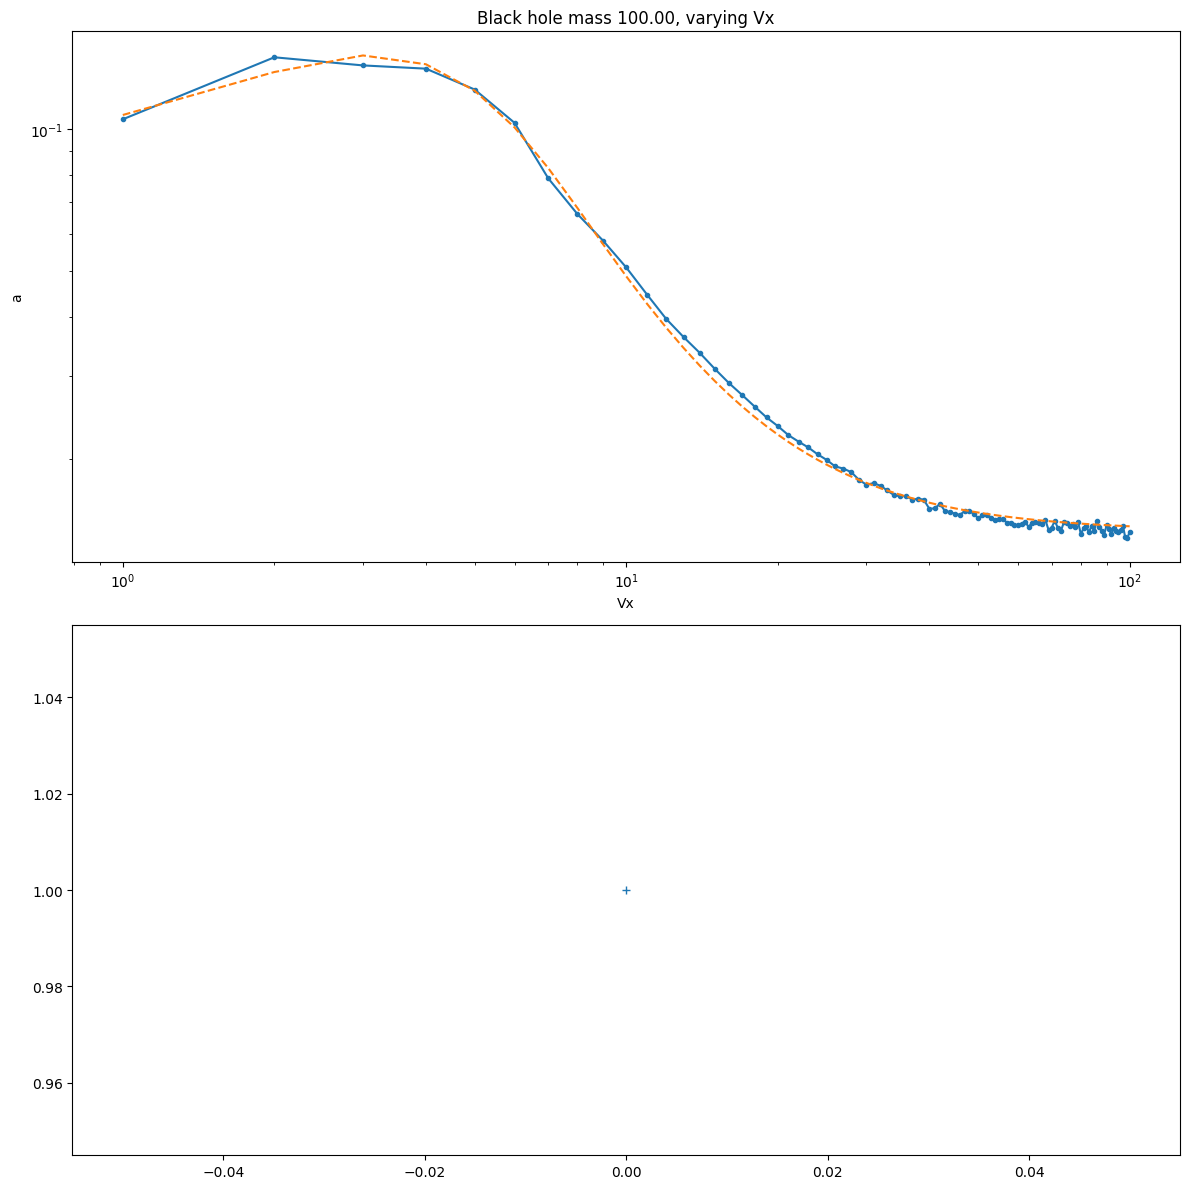

In [ ]:
Ms = np.linspace(10,100,10) #Massa gas
ms = np.linspace(10,100,10) #Massa BH
Vxs = np.linspace(1,100,100) #Velocità relativa
scanfolder = "scan10000"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

def line(x,a,q):
    return a*x+q

def a_v(x,c0,c1,c2):
    return c0/(x-c2)**2+c1
def a_v_based(x,c0,c1,c3):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x)**2+c1

def a_v_based_shift(x,c0,c1,c3,c2):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x-c2)**2+c1
save_first = True
fig, axs = plt.subplots(2,figsize=(12,12))
ax, axq = axs
i = 0
Mfactor = []
for M in [Ms[-1]]:
    fixed_M = [results for results in out if results["M"] == M]
    for m in [ms[-1]]:
        fixed_m = [results for results in fixed_M if results["m"] == m]
        a = -np.array([results["a"] for results in fixed_m])
        if save_first:
            aa = a
            save_first = False
        Mfactor.append(np.mean(a/aa))
        xVx = np.array([results["Vx"] for results in fixed_m])
        cut = xVx > 0

        # cut = xVx > 
        popt1, _ = curve_fit(a_v_based,xVx[cut],a[cut],p0=[1,0.001,0.26])
        popt2, _ = curve_fit(a_v_based_shift,xVx[cut],a[cut],p0=np.r_[popt1,-1])
        # print(popt2)
        print(a)
        print(f"{1/(np.sqrt(2)*popt2[2])/np.sqrt(2)}")
        ax.plot(xVx,a,".-C0")
        # ax.plot(xVx[cut],a_v_based(xVx[cut],*popt1),"--C2")
        ax.plot(xVx[cut],a_v_based_shift(xVx[cut],*popt2),"--C1")
        ax.set_xlabel("Vx")
        ax.set_ylabel("a")
        ax.set_xscale("log")
        ax.set_yscale("log")

xfit = np.arange(len(Mfactor))

axq.plot(xfit,Mfactor,'+C0')

ax.set_title(f"Black hole mass {m:0.2f}, varying Vx")
plt.tight_layout()

plt.show()



In [10]:
print(out)

[]
